In [128]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

In [155]:
Main.include("..\\core\\constants.jl")
Main.include("..\\core\\setting.jl")
Main.include("..\\core\\alpha_s.jl") 

Main.include("..\\diff eqn.jl")


<PyCall.jlwrap Diff_func>

In [156]:
Main.αs_Z = 0.118

In [157]:
zlist = np.linspace(0.0,0.01,10000)

Q=91.2

chi_array = []

Diffq_array_4p18 = []
Diffg_array_4p18 = []
Diffq_array_60 = []
Diffg_array_60 = []
Diffq_array_300 = []
Diffg_array_300 = []
Diffq_array_1000 = []
Diffg_array_1000 = []
Diffq_array_5000 = []
Diffg_array_5000 = []

for z in zlist:

    chi = np.arccos(1-2*z)
    chi_array.append(chi)

    Diffq_4p18, Diffg_4p18 = Main.Diff_func(z=z, Q=Q, μf=4.18)
    Diffq_60, Diffg_60 = Main.Diff_func(z=z, Q=Q, μf=60.0)
    Diffq_300, Diffg_300 = Main.Diff_func(z=z, Q=Q, μf=300.0)
    Diffq_1000, Diffg_1000 = Main.Diff_func(z=z, Q=Q, μf=1000.0)
    Diffq_5000, Diffg_5000 = Main.Diff_func(z=z, Q=Q, μf=5000.0)

    Diffq_array_4p18.append(Diffq_4p18)
    Diffg_array_4p18.append(Diffg_4p18)
    Diffq_array_60.append(Diffq_60)
    Diffg_array_60.append(Diffg_60)
    Diffq_array_300.append(Diffq_300)
    Diffg_array_300.append(Diffg_300)
    Diffq_array_1000.append(Diffq_1000)
    Diffg_array_1000.append(Diffg_1000)
    Diffq_array_5000.append(Diffq_5000)
    Diffg_array_5000.append(Diffg_5000)

chi_array = np.array(chi_array)

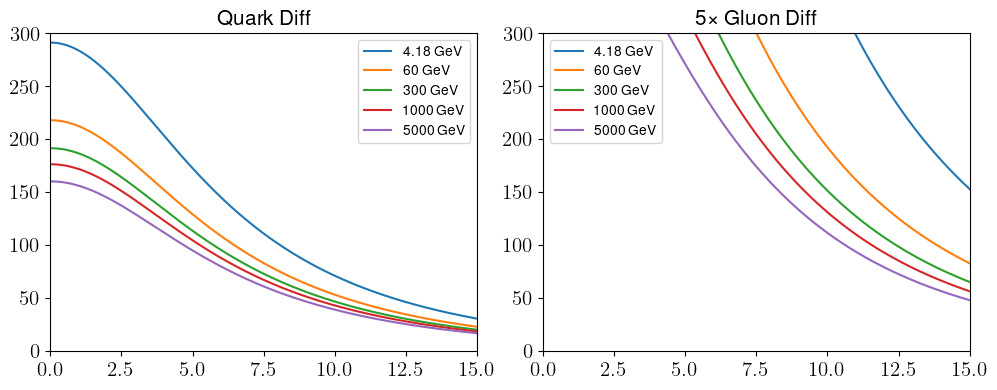

In [160]:
import matplotlib.pyplot as plt
import numpy as np

sizeOfTick = 15

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))   # 1 row, 2 columns

# ---------------- left subplot: quarks -----------------------------
ax1.plot(chi_array*Q, Diffq_array_4p18,  label="4.18 GeV")
ax1.plot(chi_array*Q, Diffq_array_60,    label="60 GeV")
ax1.plot(chi_array*Q, Diffq_array_300,   label="300 GeV")
ax1.plot(chi_array*Q, Diffq_array_1000,  label="1000 GeV")
ax1.plot(chi_array*Q, Diffq_array_5000,  label="5000 GeV")

ax1.set_xlim(0, 15.0)
ax1.set_ylim(0, 300)
ax1.set_title("Quark Diff", fontsize=sizeOfTick)
ax1.legend()
ax1.tick_params(labelsize=sizeOfTick)

# ---------------- right subplot: 5× gluons -------------------------
ax2.plot(chi_array*Q, 5*np.array(Diffg_array_4p18),  label="4.18 GeV")
ax2.plot(chi_array*Q, 5*np.array(Diffg_array_60),    label="60 GeV")
ax2.plot(chi_array*Q, 5*np.array(Diffg_array_300),   label="300 GeV")
ax2.plot(chi_array*Q, 5*np.array(Diffg_array_1000),  label="1000 GeV")
ax2.plot(chi_array*Q, 5*np.array(Diffg_array_5000),  label="5000 GeV")

ax2.set_xlim(0, 15.0)
ax2.set_ylim(0, 300)
ax2.set_title("5× Gluon Diff", fontsize=sizeOfTick)
ax2.legend()
ax2.tick_params(labelsize=sizeOfTick)

plt.tight_layout()
plt.show()

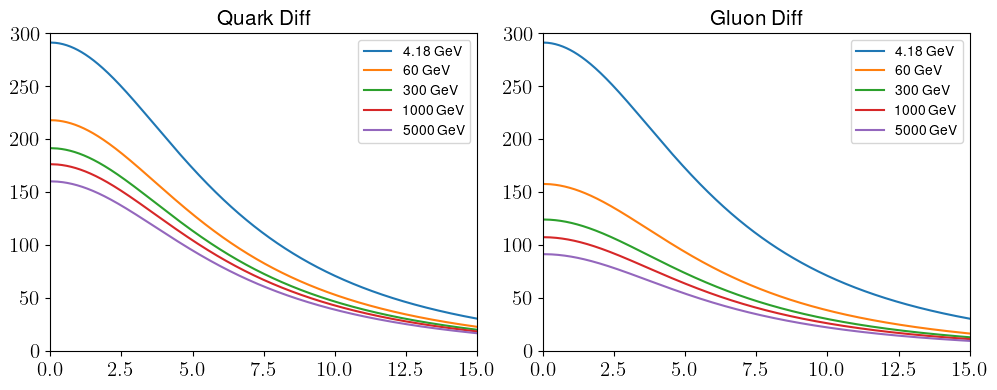

In [162]:
import matplotlib.pyplot as plt
import numpy as np

sizeOfTick = 15

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))   # 1 row, 2 columns

# ---------------- left subplot: quarks -----------------------------
ax1.plot(chi_array*Q, Diffq_array_4p18,  label="4.18 GeV")
ax1.plot(chi_array*Q, Diffq_array_60,    label="60 GeV")
ax1.plot(chi_array*Q, Diffq_array_300,   label="300 GeV")
ax1.plot(chi_array*Q, Diffq_array_1000,  label="1000 GeV")
ax1.plot(chi_array*Q, Diffq_array_5000,  label="5000 GeV")

ax1.set_xlim(0, 15.0)
ax1.set_ylim(0, 300)
ax1.set_title("Quark Diff", fontsize=sizeOfTick)
ax1.legend()
ax1.tick_params(labelsize=sizeOfTick)

# ---------------- right subplot: 5× gluons -------------------------
ax2.plot(chi_array*Q, np.array(Diffg_array_4p18),  label="4.18 GeV")
ax2.plot(chi_array*Q, np.array(Diffg_array_60),    label="60 GeV")
ax2.plot(chi_array*Q, np.array(Diffg_array_300),   label="300 GeV")
ax2.plot(chi_array*Q, np.array(Diffg_array_1000),  label="1000 GeV")
ax2.plot(chi_array*Q, np.array(Diffg_array_5000),  label="5000 GeV")

ax2.set_xlim(0, 15.0)
ax2.set_ylim(0, 300)
ax2.set_title("Gluon Diff", fontsize=sizeOfTick)
ax2.legend()
ax2.tick_params(labelsize=sizeOfTick)

plt.tight_layout()
plt.show()

In [11]:
import pandas as pd
import numpy as np

χ_lower = 1.0
χ_upper = 179

#-------------------------------------------------------------------
#dataset_names = ["OPAL"]
#-------------------------------------------------------------------
#-------------------------------------------------------------------
dataset_names = ["OPAL","SLD","TOPAZ_595","TOPAZ_533",
                 "TASSO_435","TASSO_348","MARKII","MAC"]
#-------------------------------------------------------------------

dataset_qua = ["OPAL_new","OPAL","MAC"]  
 
df_qua = {}

for name in dataset_qua:
    file_path = f"../data/{name}.csv"
    df = pd.read_csv(file_path)
    
    χ = df["CHI"]
    EEC = df["EEC"]
    ERROR = df["STAT"]
    
    df1 = pd.DataFrame({"CHI": χ, "EEC": EEC, "ERROR": ERROR})
    df_qua[name] = df1

dataset_ss = ["SLD","DELPHI","TOPAZ_595","TOPAZ_533","TASSO_435","TASSO_348","MARKII"]

df_ss = {}

for name in dataset_ss:
    file_path = f"../data/{name}.csv"
    df = pd.read_csv(file_path)
    
    χ = df["CHI"]
    EEC = df["EEC"]
    ERROR = np.sqrt(df["STAT"]**2+df["SYS"]**2)
    
    df1 = pd.DataFrame({"CHI": χ, "EEC": EEC, "ERROR": ERROR})
    df_ss[name] = df1

df = df_qua
df.update(df_ss)

df_truncated = {}
χ_list = {}
EEC = {}
ERROR = {}

Q_list = {}
Q_list["SLD"]       = 91.2
Q_list["OPAL"]      = 91.2
Q_list["OPAL_new"]      = 91.2
#Q_list["OPAL"]      = 500.0
Q_list["DELPHI"]    = 91.2
Q_list["TOPAZ_595"] = 59.5
Q_list["TOPAZ_533"] = 53.3
Q_list["TASSO_435"] = 43.5
Q_list["TASSO_348"] = 34.8
Q_list["MARKII"]    = 29.0
Q_list["MAC"]       = 29.0

for name in dataset_names:
    df_truncated[name] = df[name][(df[name]["CHI"] <= χ_upper) & (df[name]["CHI"] >= χ_lower)]

    χ_list[name] = np.array(df_truncated[name]["CHI"])
    EEC[name] = np.array(df_truncated[name]["EEC"])
    ERROR[name] = np.array(df_truncated[name]["ERROR"])

In [4]:
χlist = np.linspace(χ_lower,χ_upper,1000)

EEC_LO = []
EEC_NLO = []
EEC_NNLO = []
EEC_LL_matched = []
EEC_NLL_matched = []
EEC_NNLL_matched = []
EEC_z = []

for x in χlist:
    #LL = Main.sigma_χ(χ=χ, Q=91.2, 
    #                μ_ini=91.2, αs_ini=0.118, order=0, nf=5)
    #NLL = Main.sigma_χ(χ=χ, Q=91.2, 
    #                μ_ini=91.2, αs_ini=0.118, order=1, nf=5)
    #NNLL = Main.sigma_χ(χ=χ, Q=91.2, 
    #                μ_ini=91.2, αs_ini=0.118, order=2, nf=5)
    χ = x*np.pi/180
    LO = Main.perturbation_sigma_χ(Q=91.2, χ=χ, μ_ini=91.2, αs_ini=0.118, nf=5, order=1)
    NLO = Main.perturbation_sigma_χ(Q=91.2, χ=χ, μ_ini=91.2, αs_ini=0.118, nf=5, order=2)
    NNLO = Main.perturbation_sigma_χ(Q=91.2, χ=χ, μ_ini=91.2, αs_ini=0.118, nf=5, order=3)
    
    #non_singular_0 = Main.non_singular_sigma_χ(Q=91.2, χ=χ, μ_ini=91.2, αs_ini=0.118, nf=5, order=0)
    #non_singular_1 = Main.non_singular_sigma_χ(Q=91.2, χ=χ, μ_ini=91.2, αs_ini=0.118, nf=5, order=1)

    EEC_LO.append(LO)
    EEC_NLO.append(NLO)
    EEC_NNLO.append(NNLO)

    z = 0.5*(1-np.cos(χ))
    EEC_z.append(0.5*np.sin(χ)*Main.perturbation_func(Q=91.2, z=z, μ_ini=91.2, αs_ini=0.118, nf=5, order=3))
    #EEC_LL_matched.append(LL+non_singular_0) 
    #EEC_NLL_matched.append(NLL+non_singular_1)
    #EEC_NNLL_matched.append(NNLL+non_singular_1)    

NameError: name 'χ_lower' is not defined

In [12]:
import pandas as pd

df_LO = pd.read_csv("../fixed order/EECLO.csv",header=None)
df_NLO = pd.read_csv("../fixed order/EECNLO.csv",header=None)
df_NNLO = pd.read_csv("../fixed order/EECNNLO.csv",header=None)

CHI_LO = df_LO.iloc[:, 0]
CHI_NLO = df_NLO.iloc[:, 0]
CHI_NNLO = df_NNLO.iloc[:, 0]

numerical_LO = df_LO.iloc[:, 1]
numerical_NLO = df_NLO.iloc[:, 1]
numerical_NNLO = df_NNLO.iloc[:, 1]

ERROR_LO = df_LO.iloc[:, 2]
ERROR_NLO = df_NLO.iloc[:, 2]
ERROR_NNLO = df_NNLO.iloc[:, 2]

a=0.118/(2*np.pi)
total=a*numerical_LO+a**2*numerical_NLO+a**3*numerical_NNLO

NameError: name 'χlist' is not defined

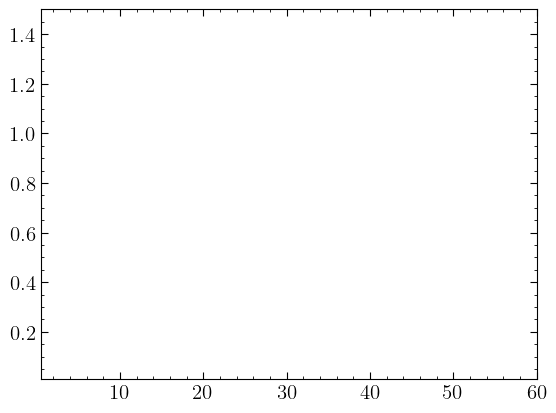

In [7]:
sizeOfTick = 15
plt.minorticks_on()
plt.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
plt.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)

plt.xlim(0.5,60)
plt.ylim(0.01,1.5)
#plt.xticks([0,0.05,0.1,0.15,0.2])
#plt.yticks([0.01,0.02,0.03])
plt.plot(χlist, EEC_LO, label="LO", color="green")
plt.plot(χlist, EEC_NLO, label="NLO", color="blue")
plt.plot(χlist, EEC_NNLO, label="NNLO", color="red")
#plt.plot(χlist, EEC_z, label="z")
#plt.plot(CHI_LO, total, label="EEC")
#plt.plot(χlist*180/np.pi, EEC_LL_matched, label="LL_matched")
#plt.plot(χlist*180/np.pi, EEC_NLL_matched, label="NLL_matched")
#plt.plot(χlist*180/np.pi, EEC_NNLL_matched, label="NNLL_matched")
plt.errorbar(χ_list["OPAL"], EEC["OPAL"], ERROR["OPAL"], label="OPAL", fmt='o', capsize=2,markersize=1,color="black")
#plt.plot(zlist, simplified, label="simp")
#plt.yscale('log')
plt.legend()

In [13]:
χlist = np.linspace(χ_lower,χ_upper,1000)

EEC_LO = []
EEC_NLO = []
EEC_NNLO = []
EEC_LL_matched = []
EEC_NLL_matched = []
EEC_NNLL_matched = []

Q = 91.2

for x in χlist:
    #LL = Main.sigma_χ(χ=χ, Q=91.2, 
    #                μ_ini=91.2, αs_ini=0.118, order=0, nf=5)
    #NLL = Main.sigma_χ(χ=χ, Q=91.2, 
    #                μ_ini=91.2, αs_ini=0.118, order=1, nf=5)
    #NNLL = Main.sigma_χ(χ=χ, Q=91.2, 
    #                μ_ini=91.2, αs_ini=0.118, order=2, nf=5)
    χ = x*np.pi/180
    LO = Main.non_singular_sigma_χ(Q=Q, χ=χ, μ_ini=91.2, αs_ini=0.118, nf=5, order=0)
    NLO = Main.non_singular_sigma_χ(Q=Q, χ=χ, μ_ini=91.2, αs_ini=0.118, nf=5, order=1)
    NNLO = Main.non_singular_sigma_χ(Q=Q, χ=χ, μ_ini=91.2, αs_ini=0.118, nf=5, order=2)
    
    #non_singular_0 = Main.non_singular_sigma_χ(Q=91.2, χ=χ, μ_ini=91.2, αs_ini=0.118, nf=5, order=0)
    #non_singular_1 = Main.non_singular_sigma_χ(Q=91.2, χ=χ, μ_ini=91.2, αs_ini=0.118, nf=5, order=1)

    EEC_LO.append(LO)
    EEC_NLO.append(NLO)
    EEC_NNLO.append(NNLO)
    #EEC_LL_matched.append(LL+non_singular_0) 
    #EEC_NLL_matched.append(NLL+non_singular_1)
    #EEC_NNLL_matched.append(NNLL+non_singular_1)   

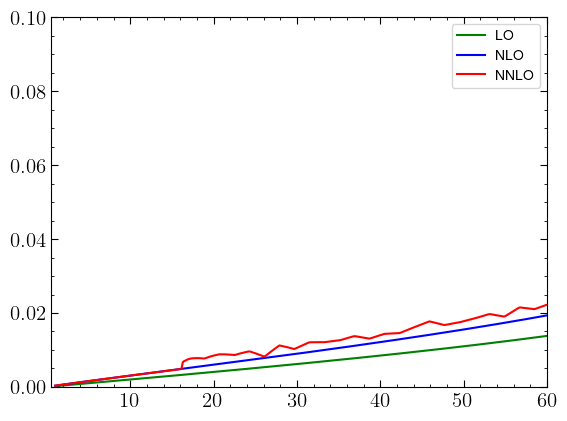

In [14]:
sizeOfTick = 15
plt.minorticks_on()
plt.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
plt.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)

plt.xlim(0.5,60)
plt.ylim(0,0.1)
#plt.xticks([0,0.05,0.1,0.15,0.2])
#plt.yticks([0.01,0.02,0.03])
plt.plot(χlist, EEC_LO, label="LO", color="green")
plt.plot(χlist, EEC_NLO, label="NLO", color="blue")
plt.plot(χlist, EEC_NNLO, label="NNLO", color="red")
#plt.plot(CHI_LO, total, label="EEC")
#plt.plot(χlist*180/np.pi, EEC_LL_matched, label="LL_matched")
#plt.plot(χlist*180/np.pi, EEC_NLL_matched, label="NLL_matched")
#plt.plot(χlist*180/np.pi, EEC_NNLL_matched, label="NNLL_matched")
#plt.errorbar(χ_list["OPAL"], EEC["OPAL"], ERROR["OPAL"], label="OPAL", fmt='o', capsize=2,markersize=1,color="black")
#plt.plot(zlist, simplified, label="simp")
#plt.yscale('log')
plt.legend()

In [14]:
np.arccos(1-2*0.02)*180/np.pi

16.260204708311967

In [15]:
EEC_NNLO = []
for x in χ_list["OPAL"]:

    r = Main.R_ratio(Q=91.2, μ_ini=91.2, αs_ini=0.118, nf=5)

    χ = x*np.pi/180
    LO = Main.perturbation_sigma_χ(Q=91.2, χ=χ, μ_ini=91.2, αs_ini=0.118, nf=5, order=1)/r
    NLO = Main.perturbation_sigma_χ(Q=91.2, χ=χ, μ_ini=91.2, αs_ini=0.118, nf=5, order=2)/r
    NNLO = Main.perturbation_sigma_χ(Q=91.2, χ=χ, μ_ini=91.2, αs_ini=0.118, nf=5, order=3)/r
    EEC_NNLO.append(NNLO)

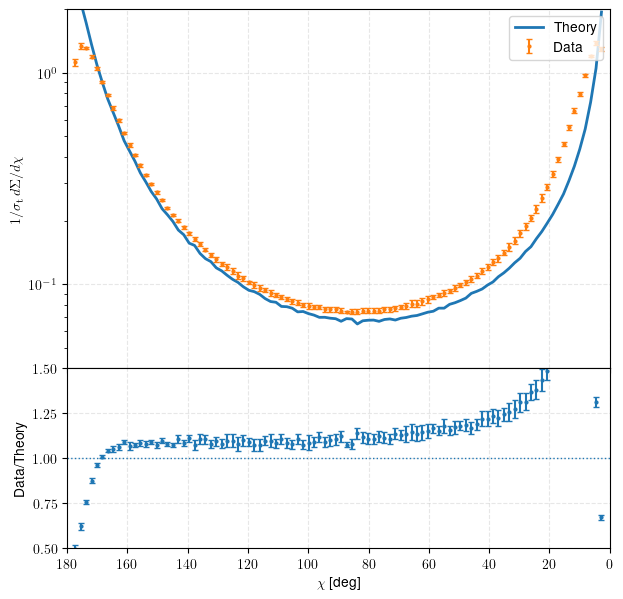

In [16]:
import numpy as np
import matplotlib.pyplot as plt

data_chi = χ_list["OPAL"]                             # data x-values
data_y = EEC["OPAL"]
data_err = ERROR["OPAL"]                                   # data uncertainties

# Interpolate theory at data points for ratio plot
theory_at_data = EEC_NNLO
ratio = data_y / theory_at_data
ratio_err = data_err / theory_at_data

# Create figure with two panels
fig = plt.figure(figsize=(7, 7))
gs = fig.add_gridspec(2, 1, height_ratios=[2, 1], hspace=0.0)
ax_main = fig.add_subplot(gs[0])
ax_ratio = fig.add_subplot(gs[1], sharex=ax_main)

# Top panel: theory curve and data points
ax_main.plot(data_chi, theory_at_data, linestyle='-', linewidth=2, label='Theory')
ax_main.errorbar(data_chi, data_y, yerr=data_err, fmt='o', capsize=2, markersize=2, label='Data')
ax_main.set_ylabel(r'$1/\sigma_{\rm t}\,d\Sigma/d\chi$')
ax_main.legend(loc='upper right')
ax_main.set_xlim(0, 180)
ax_main.set_xticks(np.arange(0, 181, 20))
ax_main.set_yticks(np.arange(0, 1.3, 0.2))
ax_main.grid(True, ls='--', alpha=0.3)
ax_main.set_xlim(180, 0)
ax_main.set_ylim(0.04, 2)
ax_main.set_yscale("log")

# Bottom panel: ratio
ax_ratio.errorbar(data_chi, ratio, yerr=ratio_err, fmt='o', capsize=2, markersize=2)
ax_ratio.axhline(1, linestyle=':', linewidth=1)
ax_ratio.set_xlabel(r'$\chi$ [deg]')
ax_ratio.set_ylabel('Data/Theory')
ax_ratio.set_xlim(0, 180)
ax_ratio.set_xticks(np.arange(0, 181, 20))
ax_ratio.set_yticks(np.arange(0.5, 1.6, 0.25))
ax_ratio.grid(True, ls='--', alpha=0.3)
ax_ratio.set_xlim(180, 0)
ax_ratio.set_ylim(0.5, 1.5)

# Hide x-tick labels on the top panel
plt.setp(ax_main.get_xticklabels(), visible=False)

plt.show()



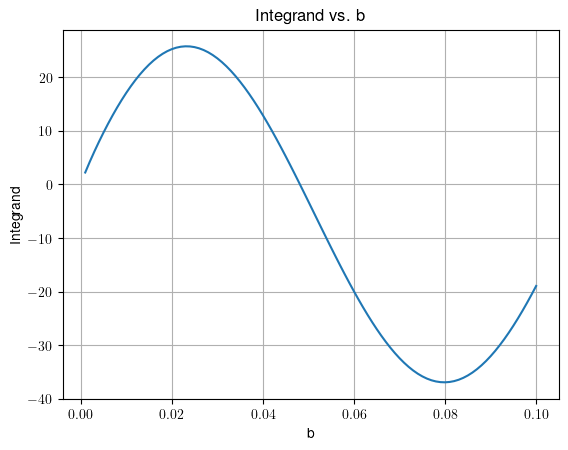

In [9]:
import numpy as np
import matplotlib.pyplot as plt

b_values = np.linspace(0.001, 0.1, 100)

Q         = 91.2
z         = 0.3
order     = 2
nf        = 5
params    = [0.86, 2.67, 1.13]
μJ_ratio  = 1.0

as_value = Main.alpha_s_func(μf=Q, μi=91.2, αs=0.118, order=3, nf=5) / (4 * np.pi)

integrand_values = []
for b in b_values:
    kwargs = {
        "b":        b,
        "z":        z,
        "Q":        Q,
        "as":       as_value,     
        "order":    order,
        "nf":       nf,
        "params":   params,
        "μJ_ratio": μJ_ratio
    }
    val = Main.Integrand_func(**kwargs)
    integrand_values.append(val)

integrand_values = np.array(integrand_values)

plt.figure()
plt.plot(b_values, integrand_values)
plt.xlabel("b")
plt.ylabel("Integrand")
plt.title("Integrand vs. b")
plt.grid(True)
plt.show()
